2025-03-19 23:35:22,417 - INFO - Loading spectral data...
2025-03-19 23:35:22,419 - INFO - Processing RGB data...
2025-03-19 23:35:22,420 - INFO - Applying tone curve correction based on white and black patches...
2025-03-19 23:35:22,420 - INFO - Normalizing RGB data...
2025-03-19 23:35:22,422 - INFO - Training the model...
2025-03-19 23:35:22,430 - INFO - Epoch 1/2000 - Training Loss: 0.7809 - Validation Loss: 0.5489
2025-03-19 23:35:22,438 - INFO - Epoch 2/2000 - Training Loss: 0.3122 - Validation Loss: 0.2834
2025-03-19 23:35:22,446 - INFO - Epoch 3/2000 - Training Loss: 0.2058 - Validation Loss: 0.2237
2025-03-19 23:35:22,453 - INFO - Epoch 4/2000 - Training Loss: 0.1671 - Validation Loss: 0.1807
2025-03-19 23:35:22,460 - INFO - Epoch 5/2000 - Training Loss: 0.1388 - Validation Loss: 0.1548
2025-03-19 23:35:22,468 - INFO - Epoch 6/2000 - Training Loss: 0.1170 - Validation Loss: 0.1330
2025-03-19 23:35:22,475 - INFO - Epoch 7/2000 - Training Loss: 0.0997 - Validation Loss: 0.1160
20

Early stopping triggered after 50 epochs with no improvement.
Mean ΔE2000 Error: 5.656724766060024
Max ΔE2000 Error: 15.814037882277988


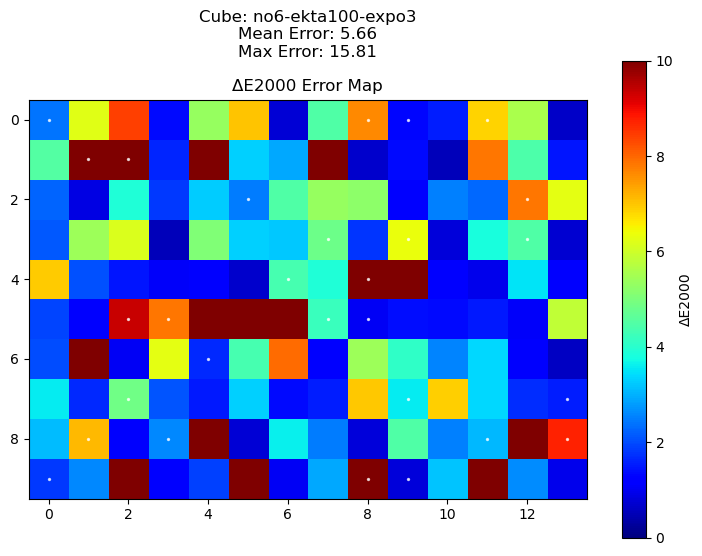

2025-03-19 23:35:25,018 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04364112..1.0100305].


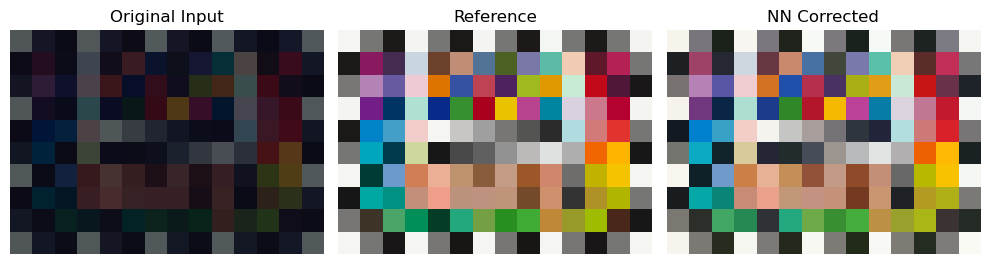

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import copy
import os


# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_rgb(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data to RGB using XYZ conversion.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    
    # Convert XYZ to RGB
    rgb = color.xyz2rgb(xyz)
    return rgb

def apply_tone_curve_lab_L(lab_input, lab_ref, white_coords=(0,0), black_coords=(1,0)):
    """
    Applies tone curve correction in Lab space only on the L channel,
    using white and black patch anchors, leaving a and b unchanged.
    
    Parameters:
      lab_input: numpy array of shape (H, W, 3) with input Lab values.
      lab_ref: numpy array of shape (H, W, 3) with reference Lab values.
      white_coords: tuple (row, col) for white patch location.
      black_coords: tuple (row, col) for black patch location.
      
    Returns:
      lab_corrected: numpy array of shape (H, W, 3) after tone curve correction.
    """
    # Extract L values for white and black patches
    L_in_white = lab_input[white_coords[0], white_coords[1], 0]
    L_in_black = lab_input[black_coords[0], black_coords[1], 0]
    L_ref_white = lab_ref[white_coords[0], white_coords[1], 0]
    L_ref_black = lab_ref[black_coords[0], black_coords[1], 0]
    
    # Build tone curve for L channel
    # Map input L values [L_in_black, L_in_white] to reference L values [L_ref_black, L_ref_white]
    lab_corrected = lab_input.copy()
    L_channel = lab_input[..., 0].flatten()
    L_corrected = np.interp(L_channel, [L_in_black, L_in_white], [L_ref_black, L_ref_white])
    lab_corrected[..., 0] = L_corrected.reshape(lab_input.shape[:2])
    # a and b channels remain unchanged.
    return lab_corrected

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube_path = '../../data/colorChecker_SG/cubes/cubeCC_no6-ekta100-expo3.hdr'
cube = spectral.open_image(cube_path)
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process RGB data
###########################################
logging.info('Processing RGB data...')
rgb_input = process_rgb(cube_data, wl_input, ill, CMFs)   
rgb_ref   = process_rgb(cube_ref_data, wl_ref, ill, CMFs)   

H, W, C = rgb_input.shape
rgb_input_2d = rgb_input.reshape(H, W, C)
rgb_ref_2d   = rgb_ref.reshape(H, W, C)

# Tone Curve Correction (Pre-processing Step)
# logging.info('Applying tone curve correction based on white and black patches...')

# Assume the chart is arranged in a 10x14 grid.
#  white patch at (0,0) and black patch at (1,0)
# rgb_input = apply_tone_curve(rgb_input_2d, rgb_ref_2d, white_coords=(0,0), black_coords=(1,0))


###########################################
# 3. Normalize data in RGB space
###########################################
logging.info('Normalizing RGB data...')
rgb_input_2d = rgb_input.reshape(-1, rgb_input.shape[-1])
rgb_ref_2d   = rgb_ref.reshape(-1, rgb_ref.shape[-1])

# scaler_input = MinMaxScaler()
# scaler_ref = MinMaxScaler()
# X_norm = scaler_input.fit_transform(rgb_input_2d)
# Y_norm = scaler_ref.fit_transform(rgb_ref_2d)


scaler_input = StandardScaler()
scaler_ref = StandardScaler()
X_norm = scaler_input.fit_transform(rgb_input_2d)
Y_norm = scaler_ref.fit_transform(rgb_ref_2d)

X_full = X_norm.reshape(rgb_input.shape)
Y_full = Y_norm.reshape(rgb_ref.shape)

###########################################
# 4. Prepare training data
###########################################
X_flat = X_full.reshape(-1, 3)
Y_flat = Y_full.reshape(-1, 3)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 5. Define a simple MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))
    
    
    

class HybridRGBLoss(nn.Module):
    def __init__(self, alpha=0.5, eps=1e-6):
        super(HybridRGBLoss, self).__init__()
        self.alpha = alpha  
        self.eps = eps  
        self.mse_loss = nn.MSELoss()

    def forward(self, y_pred, y_true):
        y_pred_norm = torch.nn.functional.normalize(y_pred, p=2, dim=1, eps=self.eps)
        y_true_norm = torch.nn.functional.normalize(y_true, p=2, dim=1, eps=self.eps)
        cosine_similarity = torch.sum(y_pred_norm * y_true_norm, dim=1)
        cosine_similarity = torch.clamp(cosine_similarity, -1.0, 1.0)
        angular_loss = 1 - cosine_similarity  
        mse_loss = self.mse_loss(y_pred, y_true)
        total_loss = self.alpha * angular_loss.mean() + (1 - self.alpha) * mse_loss
        return total_loss

class EarlyStopping:
    def __init__(self, patience=10, delta=0, verbose=False, path='best_model.pth'):
        self.patience = patience  # Number of epochs to wait for improvement
        self.delta = delta  # Minimum change to qualify as an improvement
        self.verbose = verbose  # Whether to print the stop message
        self.path = path  # Path to save the best model
        self.best_loss = None  # Best validation loss
        self.counter = 0  # Counter for how many epochs without improvement
        self.early_stop = False  # Flag to stop the training
        self.best_model_wts = None  # To store the best model's weights

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
        elif val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0  # Reset the counter
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"Early stopping triggered after {self.counter} epochs with no improvement.")
                    
        return self.early_stop


model = SimpleMLP(input_size=3, hidden_size=128, output_size=3)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
# loss_function = HybridRGBLoss()
loss_function = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=300, gamma=0.5)  # Reduce LR every 200 epochs
early_stopping = EarlyStopping(patience= 50, delta = 0, verbose=True)


###########################################
# 6. Training loop (using MSE loss in RGB space)
###########################################
epochs = 2000
batch_size = 4
val_loss_min = float('inf')
train_losses = []
val_losses = []

logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    epoch_train_loss = 0.0
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
    
    # Calculate average training loss for the epoch
    avg_train_loss = epoch_train_loss / (X_train_shuffled.size(0) // batch_size)
    train_losses.append(avg_train_loss)
    
    scheduler.step()  # Reduce learning rate

    # Calculate validation loss (on the test set)
    model.eval()
    with torch.no_grad():
        Y_val_pred = model(X_test_torch)
        val_loss = loss_function(Y_val_pred, Y_test_torch).item()
    val_losses.append(val_loss)

    # Print training and validation loss
    logging.info(f'Epoch {epoch+1}/{epochs} - Training Loss: {avg_train_loss:.4f} - Validation Loss: {val_loss:.4f}')
    
    # Check for early stopping
    early_stopping(val_loss, model)
    
    if early_stopping.early_stop:
        logging.info("Early stopping triggered.")
        break

# Load the best model weights
model.load_state_dict(early_stopping.best_model_wts)

###########################################
# 7. Apply correction and evaluate with ΔE2000
###########################################
logging.info('Applying correction to the full target...')
X_full_flat = X_full.reshape(-1, 3)
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_rgb = scaler_ref.inverse_transform(corrected_flat)
corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

# Convert corrected and reference RGB to Lab
corrected_lab = color.rgb2lab(corrected_rgb_image)
lab_ref = color.rgb2lab(rgb_ref)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, corrected_lab)

# Compute mean ΔE2000 error
# Flatten the error map for indexing
error_map_flat = error_map.reshape(-1)
# Extract only test-set errors using precomputed test_indices
test_error_values = error_map_flat[test_indices]
# Compute mean & max ΔE2000 error for the test set
mean_error_test = np.mean(test_error_values)
max_error_test = np.max(test_error_values)
print("Mean ΔE2000 Error:", mean_error_test)
print("Max ΔE2000 Error:", max_error_test)

# Get train set pixel positions in the image
test_positions = np.unravel_index(test_indices, lab_ref.shape[:2])

# Plot the ΔE2000 error map
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map')

# Add text annotations for Mean and Max Error and File name
file_name = os.path.splitext(os.path.basename(cube_path))[0]
file_name = file_name.split('_', 1)[-1]

plt.text(0.5, 1.1, f'Cube: {file_name}\nMean Error: {mean_error_test:.2f}\nMax Error: {max_error_test:.2f}', 
         ha='center', va='bottom', transform=plt.gca().transAxes, fontsize=12, color='black')

# Adjust layout to ensure the annotations are visible
plt.tight_layout(pad=3.0)
plt.show()

###########################################
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(rgb_input)
plt.title('Original Input')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(rgb_ref)
plt.title('Reference')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(corrected_rgb_image)
plt.title('NN Corrected')
plt.axis('off')
plt.tight_layout()
plt.show()

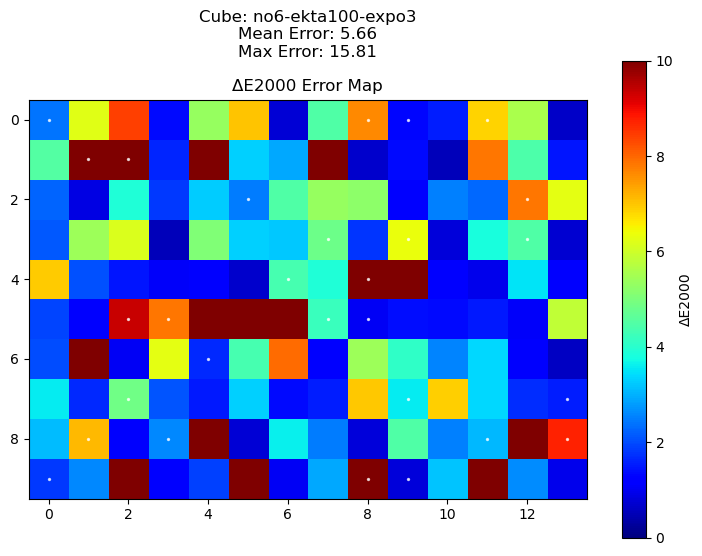

In [27]:

# Plot the ΔE2000 error map
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map')

# Add text annotations for Mean and Max Error and File name
file_name = os.path.splitext(os.path.basename(cube_path))[0]
file_name = file_name.split('_', 1)[-1]

plt.text(0.5, 1.1, f'Cube: {file_name}\nMean Error: {mean_error_test:.2f}\nMax Error: {max_error_test:.2f}', 
         ha='center', va='bottom', transform=plt.gca().transAxes, fontsize=12, color='black')

# Adjust layout to ensure the annotations are visible
plt.tight_layout(pad=3.0)
plt.show()


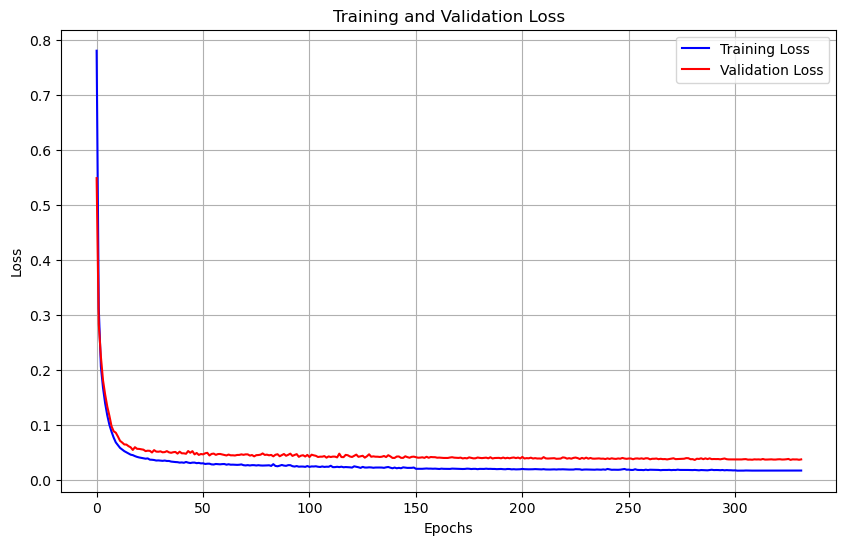

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_losses)), train_losses, label='Training Loss', color='blue')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()